# Gradient Boosting Classifier Feature Importances

Gradient Boosting classifiers sequentially train decision trees, correcting residuals/classification errors of prior steps. The trained model aggregates split metrics to determine **feature importance** (measuring how often a feature is used to divide samples across trees). This notebook trains a Gradient Boosting classifier on synthetic customer churn telemetry data and visualizes relative feature importances using Matplotlib.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Generate synthetic consumer churn telemetry (800 records, 8 features)
np.random.seed(155)
n_records = 800

# Features: Usage_Hrs, Support_Calls, Contract_Months, Age, Bill_Amt, Data_GB, Promo_Clicks, Tenure
usage_hrs = np.random.normal(45, 12, n_records)
support_calls = np.random.poisson(1.5, n_records)
contract_months = np.random.choice([1, 12, 24], size=n_records, p=[0.5, 0.3, 0.2])
age = np.random.normal(38, 8, n_records)
bill_amt = usage_hrs * 1.5 + np.random.normal(10, 5, n_records)
data_gb = np.random.exponential(15, n_records)
promo_clicks = np.random.poisson(2, n_records)
tenure = contract_months * 3 + np.random.normal(2, 1, n_records)

# Target Churn is highly correlated to support calls, tenure, and usage hours
churn_logits = 0.85 * support_calls - 0.45 * tenure - 0.05 * usage_hrs + 0.1 * age - 1.2
probs = 1 / (1 + np.exp(-churn_logits))
churn = np.random.binomial(1, probs)

df_churn = pd.DataFrame({
    'Usage_Hrs': usage_hrs,
    'Support_Calls': support_calls,
    'Contract_Months': contract_months,
    'Age': age,
    'Bill_Amt': bill_amt,
    'Data_GB': data_gb,
    'Promo_Clicks': promo_clicks,
    'Tenure': tenure,
    'Churn': churn
})

df_churn.head(10)



,Usage_Hrs,Support_Calls,Contract_Months,Age,Bill_Amt,Data_GB,Promo_Clicks,Tenure,Churn
0,52.492208,0,1,30.997156,89.786509,13.193941,1,4.071599,0
1,47.710041,3,24,40.066023,78.086969,49.002931,3,75.481868,0
2,49.994277,1,24,37.744576,90.517926,0.750760,0,73.881254,0
3,31.467162,2,24,27.945266,62.394069,3.382057,3,73.263371,0
4,43.555689,1,24,41.109893,75.719593,29.174263,1,74.143794,0
5,25.681455,3,24,39.994204,53.619621,16.785157,2,75.243174,0
6,54.006747,0,1,35.940201,91.495096,4.120170,1,6.220164,0
7,15.337512,3,24,23.872911,29.416324,1.156767,1,73.318578,0
8,54.675458,1,12,43.517373,85.832068,6.225864,3,38.773314,0
9,52.017203,1,12,34.432686,84.468195,0.775220,3,37.753790,0


## Classifier Performance Evaluation

We split variables, fit a Gradient Boosting Classifier with 100 trees and max depth of 5, and evaluate the prediction accuracy.



In [2]:
X = df_churn.drop('Churn', axis=1)
y = df_churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.08,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Gradient Boosting Churn Classifier Test Accuracy: {acc*100:.2f}%")
print("\nClassification Report Summary:")
print(classification_report(y_test, y_pred))



Gradient Boosting Churn Classifier Test Accuracy: 86.88%

Classification Report Summary:
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       124
           1       0.80      0.56      0.66        36

    accuracy                           0.87       160
   macro avg       0.84      0.76      0.79       160
weighted avg       0.86      0.87      0.86       160



## Feature Importances Ranking Visualization

We extract relative feature importances, sort them, and plot them in a horizontal Matplotlib bar chart.



<cell>:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



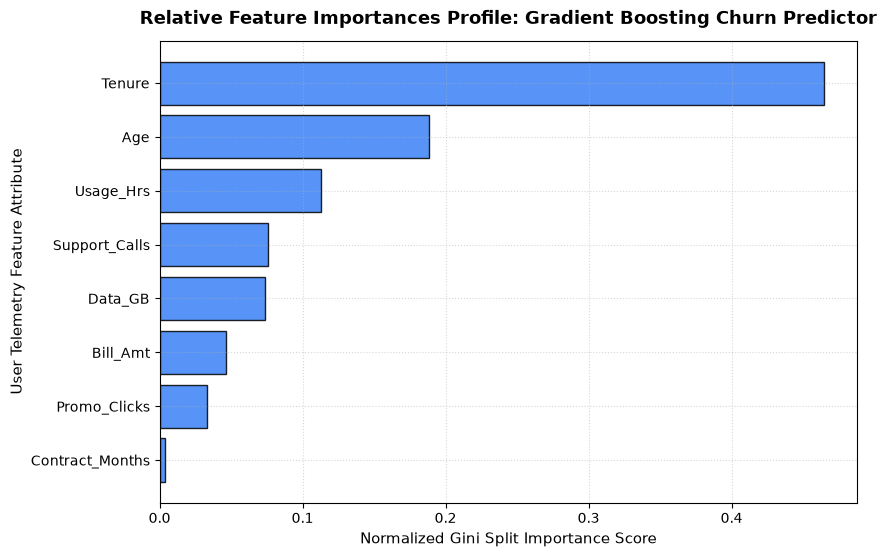

In [3]:
importances = model.feature_importances_
feature_names = X.columns

# Sort in ascending order for horizontal bar chart
sorted_indices = np.argsort(importances)
sorted_features = feature_names[sorted_indices]
sorted_importances = importances[sorted_indices]

plt.figure(figsize=(9, 6))

plt.barh(
    sorted_features, 
    sorted_importances, 
    color='#3B82F6', 
    edgecolor='black', 
    alpha=0.85
)

plt.title('Relative Feature Importances Profile: Gradient Boosting Churn Predictor', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Normalized Gini Split Importance Score', fontsize=11)
plt.ylabel('User Telemetry Feature Attribute', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
